# importing the Labaries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [8]:
df=pd.read_csv('/content/gld_price_data.csv')

In [9]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [10]:
df.shape

(2290, 6)

In [11]:
# getting some basics information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [12]:
# cheking the mising value
df.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [13]:
# getting the statical measures of the data
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


# Correlation
# 1 possitive correlation
# 2 negative correlation

In [19]:
correlation=df.drop('Date', axis=1).corr()

<Axes: >

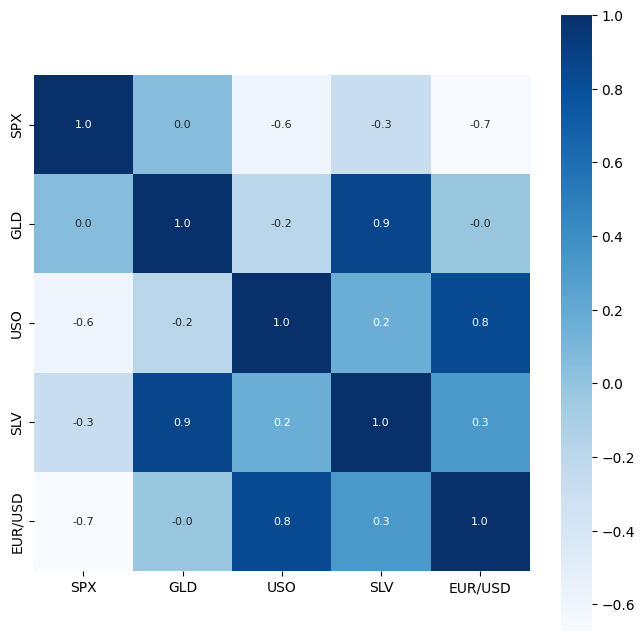

In [20]:
# constructing a heatmap to understand the correlation
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [21]:
# correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipython-input-1355983296.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

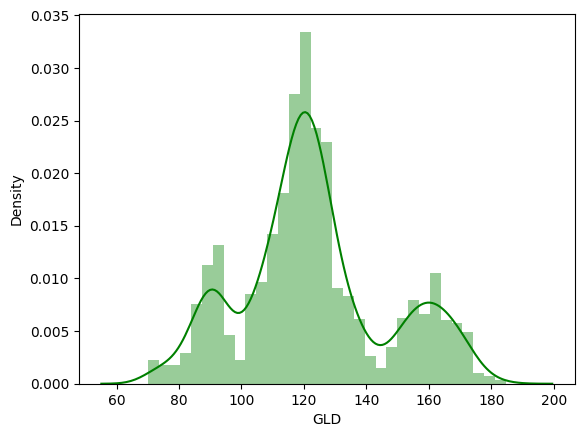

In [22]:
# cheking the distribution of Gld
sns.distplot(df['GLD'],color='green')

# Spliting the feature and Target

In [23]:
x=df.drop(['GLD','Date'],axis=1)
y=df['GLD']

In [24]:
x

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.1800,1.471692
1,1447.160034,78.370003,15.2850,1.474491
2,1411.630005,77.309998,15.1670,1.475492
3,1416.180054,75.500000,15.0530,1.468299
4,1390.189941,76.059998,15.5900,1.557099
...,...,...,...,...
2285,2671.919922,14.060000,15.5100,1.186789
2286,2697.790039,14.370000,15.5300,1.184722
2287,2723.070068,14.410000,15.7400,1.191753
2288,2730.129883,14.380000,15.5600,1.193118


In [26]:
y

,GLD
0,84.860001
1,85.570000
2,85.129997
3,84.769997
4,86.779999
...,...
2285,124.589996
2286,124.330002
2287,125.180000
2288,124.489998


# Spliting the training and test data

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [28]:
x_train

,SPX,USO,SLV,EUR/USD
476,1138.500000,39.790001,16.889999,1.361693
1958,2202.939941,10.630000,15.800000,1.063886
248,700.820007,24.480000,12.770000,1.256408
2231,2656.000000,11.890000,15.570000,1.225280
1325,1838.880005,33.040001,19.420000,1.366998
...,...,...,...,...
1071,1409.150024,32.320000,32.980000,1.287515
433,1132.989990,40.270000,17.230000,1.442398
674,1286.119995,38.610001,27.389999,1.357276
1099,1461.890015,33.919998,29.180000,1.306745


In [29]:
RandomForestRegressor=RandomForestRegressor(n_estimators=100)

In [30]:
# traing the model
RandomForestRegressor.fit(x_train,y_train)

RandomForestRegressor()

# Model evalution

In [34]:
# prediction on test Data
test_data_prediction=RandomForestRegressor.predict(x_test)

In [35]:
print(test_data_prediction)

[168.4513997   81.81830001 115.89360031 127.74930062 120.58630142
 154.62409727 150.70929953 126.05060002 117.4918986  125.95570132
 116.42770086 172.19370071 141.56689854 167.61039881 115.06659966
 117.55540038 139.02740328 170.13040134 159.41080287 159.84449957
 155.07990029 125.2548999  175.83259927 156.54190372 125.20090031
  93.80669971  77.15550017 120.6231999  119.08699923 167.39449964
  88.24040066 125.21679992  91.11310066 117.67160034 121.21159962
 136.49310077 115.42760105 115.24430054 147.79080019 107.22590083
 104.12320241  87.24139813 126.5185006  118.25219992 152.14349936
 119.71560006 108.30690021 108.17909849  93.08170046 127.12859764
  74.38610075 113.7815993  121.49810033 111.31929895 118.70729893
 120.80979961 159.64320012 168.41470111 147.22629715  85.56269861
  94.13720024  86.89699898  90.50860027 118.97400054 126.33950086
 127.49569982 170.27359964 122.20989903 117.38519903  98.62840019
 168.50870107 143.1485984  131.93920244 121.29650195 120.95059918
 119.56450

In [37]:
# R sqard Error
error_score=metrics.r2_score(y_test,test_data_prediction)
print('R squared error:',error_score)

R squared error: 0.9890482029988295


# Compare the actul Values and prediction values in plot

In [38]:
y_test=list(y_test)

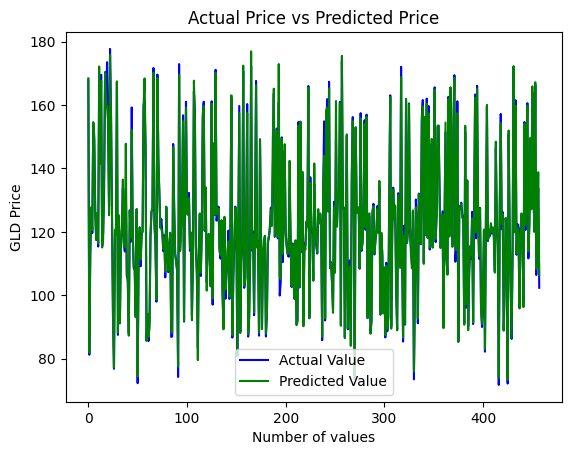

In [40]:
plt.plot(y_test,color='blue',label='Actual Value')
plt.plot(test_data_prediction,color='green',label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()